# Model Compression of the Olive Leaf CNN - Pruning and Quantization

This notebook follows the same three tasks as the class exercise
`C_Future_AI_Practical_Advances_in_ML_models_Model_Compression_Pruning_And_Quantization_v1.ipynb`,
but applied to our own saved model instead of MNIST.

**One difference from the exercise: we do not install `tensorflow-model-optimization`.**
Everything here uses libraries the main notebook already imports (TensorFlow, NumPy, matplotlib,
scikit-learn) plus two modules from the Python standard library (`tempfile`, `zipfile`).

The exercise used three things from that toolkit. Each one is replaced by a few lines we write
ourselves, keeping the same names so the two notebooks read the same way:

| Class exercise (`tfmot`) | What we use instead |
|---|---|
| `tfmot.sparsity.keras.prune_low_magnitude` | our own `prune_low_magnitude()` - a percentile and a mask |
| `tfmot.sparsity.keras.PolynomialDecay` | our own `PolynomialDecay()` - one line of arithmetic |
| `tfmot.sparsity.keras.UpdatePruningStep` | our own `UpdatePruningStep` callback - re-applies the mask |
| `tfmot.sparsity.keras.strip_pruning` | nothing - we never wrapped the model, so there is nothing to strip |

Quantization needs no replacement at all: `tf.lite` is part of TensorFlow, so the exercise's
quantization cells work unchanged.

## What this version adds

The first run of this notebook produced one measurement that could not be interpreted: the
pruned **and** quantized model scored 32.35%, which is exactly the proportion of `Healthy` images in
the test set - it had collapsed to predicting one class for everything. The pruned Keras model was
fine at 59.12%, so something in the conversion or the quantization caused it, and there was no way to
tell which.

That is a design fault in the experiment, not a mystery. Changing two things at once and measuring
only the end result cannot tell you which one was responsible. So this version builds and scores
**every combination separately**:

| | Kept in float32 | Quantized to int8 |
|---|---|---|
| **Not pruned** | baseline, and baseline converted to TFLite | quantization on its own |
| **Pruned (80%)** | pruning on its own | both together |

Reading down a column isolates pruning. Reading across a row isolates quantization. Anything that
only appears in the bottom-right corner is an interaction between the two. A float16 conversion is
included as well, because if float16 survives and int8 does not, the problem is specifically that
8 bits is too coarse for this model rather than anything wrong with the conversion.


## Before running

This notebook uses the same relative paths as the main notebook, so it must sit in the same folder
as `train/`, `test/` and `productionModel/`.

Check `MODEL_DIR` in the next cell points at the folder that actually contains `saved_model.pb`.

Order of the notebook:

1. **Task 1** - load the data and the saved model, evaluate it, save it. This is the baseline.
2. **Task 2** - pruning: mask the small weights, fine-tune, check what it cost.
3. **Task 3** - build the six models in the table above and measure the size of each.
4. **Comparison** - score all of them on the same test set, with per-class recall.
5. **Explanation** - what pruning and quantization actually do, in plain language.

Only Task 2 involves training - four short epochs. Task 3 evaluates the TFLite models one image at a
time, which is how they run on a device, so allow a couple of minutes there.


In [25]:
# libraries - the same ones the main notebook already uses

import tensorflow as tf
from tensorflow import keras
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, SpatialDropout2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
%matplotlib inline

import os
import tempfile
import zipfile

from sklearn.metrics import classification_report, f1_score, recall_score

# same image size, seed and classes as the main notebook
w = 224
h = 224
SEED = 42

CLASSES = ['Healthy', 'aculus_olearius', 'olive_peacock_spot']
num_classes = len(CLASSES)

MODEL_DIR = "productionModel/1785117387"   # the folder holding saved_model.pb

# limiting mem size (same as the main notebook)
tf.config.optimizer.set_jit(False)
physical_devices = tf.config.list_physical_devices('GPU')
gpu_memory_limit = 1024  # in MB
for device in physical_devices:
    tf.config.set_logical_device_configuration(
        device,
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=gpu_memory_limit)]
    )

print("TensorFlow:", tf.__version__)


TensorFlow: 2.12.0


## **Task 1 - Load the data and the saved model, evaluate it, save it**

The class exercise trained a small model on MNIST at this point. We already have a trained model, so
instead we rebuild the same generators the main notebook used and load the saved weights.

The generators must match the main notebook exactly, otherwise the accuracy we measure here is not
comparable to the accuracy reported there.


In [26]:
# same generators as the main notebook, so the numbers are comparable

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=10, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, vertical_flip=True, validation_split=0.3)
val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.3)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='training', shuffle=True, seed=SEED)
val_gen   = val_datagen.flow_from_directory('train', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                subset='validation', shuffle=False, seed=SEED)
test_gen  = test_datagen.flow_from_directory('test', target_size=(w, h),
                batch_size=32, class_mode='categorical', classes=CLASSES,
                shuffle=False, seed=SEED)


Found 1904 images belonging to 3 classes.
Found 816 images belonging to 3 classes.
Found 680 images belonging to 3 classes.


In [27]:
# open the saved model

saved = tf.keras.models.load_model(MODEL_DIR)
saved.summary()


Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_65 (Conv2D)          (None, 220, 220, 16)      1216      
                                                                 
 max_pooling2d_65 (MaxPoolin  (None, 110, 110, 16)     0         
 g2D)                                                            
                                                                 
 spatial_dropout2d_6 (Spatia  (None, 110, 110, 16)     0         
 lDropout2D)                                                     
                                                                 
 conv2d_66 (Conv2D)          (None, 106, 106, 32)      12832     
                                                                 
 max_pooling2d_66 (MaxPoolin  (None, 53, 53, 32)       0         
 g2D)                                                            
                                                     

A model that comes back out of a SavedModel folder is a *revived* model - its layers are
restored objects rather than the ordinary Keras layers we built. That is fine for predicting, but
pruning needs to reach into `layer.kernel`, so we rebuild the same architecture and copy the trained
weights across. This is the `modelBest` architecture from the main notebook, typed out again.


In [28]:
# rebuild modelBest and copy the trained weights in

model = Sequential()
model.add(Conv2D(16, (5, 5), activation='relu', input_shape=(w, h, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(SpatialDropout2D(0.2))
model.add(Conv2D(32, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(SpatialDropout2D(0.2))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.set_weights(saved.get_weights())
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

print("weights copied correctly:", np.allclose(model.get_weights()[0], saved.get_weights()[0]))
model.summary()


weights copied correctly: True
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 220, 220, 16)      1216      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 110, 110, 16)     0         
 2D)                                                             
                                                                 
 spatial_dropout2d_2 (Spatia  (None, 110, 110, 16)     0         
 lDropout2D)                                                     
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 32)      12832     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 53, 53, 32)       0         
 2D)                                                             
                       

In [29]:
# baseline accuracy - every later number is compared against this

test_gen.reset()
baseline_loss, baseline_model_accuracy = model.evaluate(test_gen, verbose=1)

print('Baseline test accuracy:', baseline_model_accuracy)

_, keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(model=model, filepath=keras_file, include_optimizer=False)

print('Saved baseline model to:', keras_file)


2026-08-06 14:59:28.295627: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


22/22 [==============================] - 2s 66ms/step - loss: 0.8246 - acc: 0.6103
Baseline test accuracy: 0.6102941036224365
Saved baseline model to: /tmp/tmpl36w4xft.h5


## **Task 2 - Pruning, without the model optimization toolkit**

### What pruning does

Magnitude pruning sets the smallest weights to exactly zero. A weight near zero contributes almost
nothing to the output, so removing it costs little accuracy, and once enough weights are zero the
file compresses dramatically because long runs of zeros are cheap to encode.

Han et al.'s recipe is three steps: **train, prune, retrain**. We have the trained model already, so
we do the last two.

### The three functions below

`prune_low_magnitude(model, sparsity)` builds a **mask** for each Conv2D and Dense layer. For a
sparsity of 0.5 it finds the value below which half the absolute weights fall
(`np.percentile(np.abs(kernel), 50)`) and returns a 0/1 array marking which weights survive. It
thresholds **per layer**, not globally, because the two convolutional layers hold weights on a
completely different scale to the dense layer - a single global threshold would wipe the conv layers
out entirely. Biases are never pruned, which is the standard convention.

`PolynomialDecay(...)` is the ramp. Pruning straight to 80% in one step is a shock the model may not
recover from, so sparsity climbs from 50% to 80% across the epochs, fast at first then easing off.
This is Zhu and Gupta's schedule and it is the same shape the toolkit's `PolynomialDecay` produces -
it is just one line of arithmetic.

`UpdatePruningStep` is the callback, and it is the part people miss. Gradient descent does not know
the weights are supposed to be zero, so the very next batch pushes them off zero again. The callback
re-applies the mask after every batch, which is exactly what the toolkit's callback of the same name
does.

### Why we leave the output layer alone

`PRUNE_OUTPUT_LAYER` below defaults to `False`, and that is a change from the first run.

The final `Dense(64, 3)` classifier holds **192 weights** out of 5,767,139 - roughly one
thirty-thousandth of the model. Pruning it saves nothing measurable. But at 80% sparsity it leaves
about thirteen weights per class to decide the entire output, which squeezes the gap between the
three class scores almost flat. In the first run it was pruned to 79.7%, and while the pruned Keras
model still scored 59.12%, the quantized version collapsed to a single class - consistent with a
model that had almost no margin left to lose.

Leaving the last layer at full precision is standard practice, not a fudge: `tfmot`'s own guide
recommends excluding the final classification layer, and Han et al. treated the output layer
separately for the same reason. Set the flag back to `True` if you want to reproduce the first run.


In [30]:
# our replacement for tfmot.sparsity.keras.prune_low_magnitude

PRUNE_OUTPUT_LAYER = False
OUTPUT_LAYER = model.layers[-1].name

skip_layers = () if PRUNE_OUTPUT_LAYER else (OUTPUT_LAYER,)
print("layers left unpruned:", skip_layers)


def prune_low_magnitude(model, sparsity, skip=()):
    # for each weighted layer, mark the weights big enough to keep
    masks = {}
    for layer in model.layers:
        if isinstance(layer, (Conv2D, Dense)) and layer.name not in skip:
            kernel = layer.get_weights()[0]
            threshold = np.percentile(np.abs(kernel), sparsity * 100)
            masks[layer.name] = (np.abs(kernel) > threshold).astype('float32')
    return masks


def apply_masks(model, masks):
    # write the zeros straight into the layer's kernel
    for name, mask in masks.items():
        layer = model.get_layer(name)
        layer.kernel.assign(layer.kernel * mask)


def report_sparsity(model):
    for layer in model.layers:
        if isinstance(layer, (Conv2D, Dense)):
            kernel = layer.get_weights()[0]
            zeros = 100.0 * np.mean(kernel == 0)
            print(f"  {layer.name:<22} {str(kernel.shape):<18} zeros: {zeros:5.1f} %")


layers left unpruned: ('dense_3',)


In [31]:
# our replacement for tfmot.sparsity.keras.PolynomialDecay and UpdatePruningStep

def PolynomialDecay(initial_sparsity, final_sparsity, epochs):
    # sparsity for each epoch: starts at initial, ends at final, most of the change happens early
    return [final_sparsity + (initial_sparsity - final_sparsity) * (1 - t / max(epochs - 1, 1)) ** 3
            for t in range(epochs)]


class UpdatePruningStep(tf.keras.callbacks.Callback):

    def __init__(self, schedule, skip=()):
        super().__init__()
        self.schedule = schedule
        self.skip = skip
        self.masks = {}

    def on_epoch_begin(self, epoch, logs=None):
        # tighten the pruning at the start of each epoch
        sparsity = self.schedule[epoch]
        self.masks = prune_low_magnitude(self.model, sparsity, skip=self.skip)
        apply_masks(self.model, self.masks)
        print(f"epoch {epoch + 1}: pruned to {sparsity:.0%} sparsity")

    def on_train_batch_end(self, batch, logs=None):
        # hold the pruned weights at zero - without this the optimizer undoes the pruning
        apply_masks(self.model, self.masks)


epochs = 4
schedule = PolynomialDecay(initial_sparsity=0.50, final_sparsity=0.80, epochs=epochs)
print("sparsity schedule:", [f"{s:.0%}" for s in schedule])


sparsity schedule: ['50%', '71%', '79%', '80%']


In the class exercise the model summary showed roughly double the parameters after
`prune_low_magnitude`, because the toolkit wraps every layer and stores a mask and a threshold
variable alongside each kernel. Ours does not: the mask lives in an ordinary Python dictionary
outside the model, so the parameter count is unchanged. That also means there is nothing to strip
off later.


In [32]:
# make an independent copy so the baseline model is never touched

model_for_pruning = tf.keras.models.clone_model(model)
model_for_pruning.set_weights(model.get_weights())

model_for_pruning.compile(loss='categorical_crossentropy',
                          optimizer=tf.keras.optimizers.Adam(1e-4),
                          metrics=['acc'])

model_for_pruning.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 220, 220, 16)      1216      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 110, 110, 16)     0         
 2D)                                                             
                                                                 
 spatial_dropout2d_2 (Spatia  (None, 110, 110, 16)     0         
 lDropout2D)                                                     
                                                                 
 conv2d_3 (Conv2D)           (None, 106, 106, 32)      12832     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 53, 53, 32)       0         
 2D)                                                             
                                                      

We fine-tune with Adam at `1e-4` rather than the default `1e-3`. The model is being *recovered*,
not retrained - a full learning rate would move the surviving weights so far that we would no longer
be measuring the effect of pruning.


In [33]:
# fine tune with pruning

model_for_pruning.fit(train_gen,
                      validation_data=val_gen,
                      epochs=epochs,
                      callbacks=[UpdatePruningStep(schedule, skip=skip_layers)],
                      verbose=1)


epoch 1: pruned to 50% sparsity
Epoch 1/4


2026-08-06 15:00:11.541390: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-08-06 15:00:12.186412: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/spatial_dropout2d_2/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


60/60 [==============================] - ETA: 0s - loss: 0.8167 - acc: 0.6019

2026-08-06 15:00:31.721491: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


60/60 [==============================] - 22s 344ms/step - loss: 0.8167 - acc: 0.6019 - val_loss: 0.8198 - val_acc: 0.5110
epoch 2: pruned to 71% sparsity
Epoch 2/4
60/60 [==============================] - 21s 347ms/step - loss: 0.9857 - acc: 0.5882 - val_loss: 0.8767 - val_acc: 0.5331
epoch 3: pruned to 79% sparsity
Epoch 3/4
60/60 [==============================] - 21s 343ms/step - loss: 1.0637 - acc: 0.4186 - val_loss: 1.0447 - val_acc: 0.4449
epoch 4: pruned to 80% sparsity
Epoch 4/4
60/60 [==============================] - 21s 343ms/step - loss: 0.9325 - acc: 0.5347 - val_loss: 0.9055 - val_acc: 0.4865


In [34]:
# check the zeros survived the fine-tuning, then score it

print("sparsity after fine-tuning:")
report_sparsity(model_for_pruning)

test_gen.reset()
_, model_for_pruning_accuracy = model_for_pruning.evaluate(test_gen, verbose=1)

print('\nBaseline test accuracy:', baseline_model_accuracy)
print('Pruned test accuracy:', model_for_pruning_accuracy)


sparsity after fine-tuning:
  conv2d_2               (5, 5, 3, 16)      zeros:  80.0 %
  conv2d_3               (5, 5, 16, 32)     zeros:  80.0 %
  dense_2                (89888, 64)        zeros:  80.0 %
  dense_3                (64, 3)            zeros:   0.0 %
 1/22 [>.............................] - ETA: 2s - loss: 0.9146 - acc: 0.9062

2026-08-06 15:01:47.380026: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


22/22 [==============================] - 2s 65ms/step - loss: 0.8861 - acc: 0.5882

Baseline test accuracy: 0.6102941036224365
Pruned test accuracy: 0.5882353186607361


**If the sparsity report shows 0% zeros**, the callback did not run - check it is still in the
`callbacks` list. This is the single most common way this notebook fails silently.

With `PRUNE_OUTPUT_LAYER = False` the last row of the report should read close to 0% zeros while the
other three read about 80%. That is correct, not a bug.


## **Task 3 - Switching from TF to TFLite, and adding quantization**

The class exercise called `strip_pruning` here to remove the mask and threshold variables the
toolkit added, because those would otherwise bloat the saved file. We never added them, so the
pruned model is already an ordinary Sequential model and there is nothing to strip.


In [35]:
# the exercise called strip_pruning here - we have no wrappers, so this is just a rename

model_for_export = model_for_pruning

_, pruned_keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(model_for_export, pruned_keras_file, include_optimizer=False)
print('Saved pruned Keras model to:', pruned_keras_file)


Saved pruned Keras model to: /tmp/tmpv5c983e2.h5


### Building every combination

Six TFLite files, so that pruning and quantization can be told apart:

| File | Pruned? | Weights stored as | What it isolates |
|---|---|---|---|
| `baseline_float32` | no | float32 | the conversion itself - should match the Keras baseline |
| `baseline_float16` | no | float16 | a gentle quantization, 2x smaller |
| `baseline_int8` | no | int8 | **quantization on its own** |
| `pruned_float32` | yes | float32 | **pruning on its own**, in deployment format |
| `pruned_float16` | yes | float16 | pruning plus gentle quantization |
| `pruned_int8` | yes | int8 | **both together** |

`baseline_float32` is the control that matters most. If it does not reproduce the Keras baseline
accuracy, the problem is in the conversion and nothing measured afterwards means anything.

Note what `Optimize.DEFAULT` does on its own: it is **dynamic range** quantization. The weights are
stored as int8, but the activations stay in float and are quantized on the fly at run time. It needs
no calibration data, which is why it is one line.


In [36]:
def convert_tflite(keras_model, mode):
    # mode: 'float32' (no quantization), 'float16', or 'int8' (dynamic range)
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if mode == 'float16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif mode == 'int8':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    tflite_model = converter.convert()

    _, path = tempfile.mkstemp('.tflite')
    with open(path, 'wb') as f:
        f.write(tflite_model)
    return path


In [37]:
# build all six

tflite_files = {}

for mode in ['float32', 'float16', 'int8']:
    tflite_files['baseline_' + mode] = convert_tflite(model, mode)
    tflite_files['pruned_' + mode] = convert_tflite(model_for_export, mode)

for name, path in tflite_files.items():
    print(f"{name:<20} {path}")


2026-08-06 15:02:12.876201: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-08-06 15:02:12.906728: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,?,?,?]
	 [[{{node inputs}}]]
2026-08-06 15:02:13.054876: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,64]
	 [[{{node inputs}}]]
2026-08-06 15

INFO:tensorflow:Assets written to: /tmp/tmp78dskdex/assets


INFO:tensorflow:Assets written to: /tmp/tmp78dskdex/assets
2026-08-06 15:02:13.923170: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-08-06 15:02:13.923199: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-06 15:02:13.923402: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp78dskdex
2026-08-06 15:02:13.925119: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-08-06 15:02:13.925135: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmp78dskdex
2026-08-06 15:02:13.930992: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-08-06 15:02:13.979059: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmp78dskdex
2026-08-06 15:02:13.988533: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmps_wtjga1/assets


INFO:tensorflow:Assets written to: /tmp/tmps_wtjga1/assets
2026-08-06 15:02:15.566816: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-08-06 15:02:15.566845: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-06 15:02:15.567037: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmps_wtjga1
2026-08-06 15:02:15.569349: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-08-06 15:02:15.569366: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmps_wtjga1
2026-08-06 15:02:15.577191: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-08-06 15:02:15.678510: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmps_wtjga1
2026-08-06 15:02:15.693376: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

...

INFO:tensorflow:Assets written to: /tmp/tmp463jyfm7/assets
2026-08-06 15:02:20.503004: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-08-06 15:02:20.503031: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-06 15:02:20.503218: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp463jyfm7
2026-08-06 15:02:20.504747: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-08-06 15:02:20.504762: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmp463jyfm7
2026-08-06 15:02:20.509874: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-08-06 15:02:20.556934: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmp463jyfm7
2026-08-06 15:02:20.566396: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpuibm3fhr/assets


INFO:tensorflow:Assets written to: /tmp/tmpuibm3fhr/assets


baseline_float32     /tmp/tmpkjyw9x4f.tflite
pruned_float32       /tmp/tmp98gf_cq9.tflite
baseline_float16     /tmp/tmpblhokg1j.tflite
pruned_float16       /tmp/tmpazakbyf3.tflite
baseline_int8        /tmp/tmp6hrh5oja.tflite
pruned_int8          /tmp/tmpfxesyaxl.tflite


2026-08-06 15:02:23.384151: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-08-06 15:02:23.384178: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-06 15:02:23.384376: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmpuibm3fhr
2026-08-06 15:02:23.388043: I tensorflow/cc/saved_model/reader.cc:89] Reading meta graph with tags { serve }
2026-08-06 15:02:23.388061: I tensorflow/cc/saved_model/reader.cc:130] Reading SavedModel debug info (if present) from: /tmp/tmpuibm3fhr
2026-08-06 15:02:23.395621: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-08-06 15:02:23.497001: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmpuibm3fhr
2026-08-06 15:02:23.510912: I tensorflow/cc/saved_model/loader.cc:314] SavedModel load for tags { serve }; Status: success: OK. Took 126536 

### Why we measure the *zipped* size

A pruned `.h5` file is the same size as the original. The zeros are still stored as ordinary 32-bit
floats - the model is sparse but the file format is dense. The saving only appears once the file is
compressed, because runs of zeros compress to almost nothing.

That is not a trick: a model shipped to a phone is downloaded compressed. So we report **both** the
raw file size and the zipped size, and the gap between the two columns is itself the result -
it is the visible evidence of how many zeros pruning put in.


In [38]:
def get_gzipped_model_size(file):
    # Returns size of gzipped model, in bytes.
    import os
    import zipfile

    _, zipped_file = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(file)

    return os.path.getsize(zipped_file)


def size_mb(file):
    return os.path.getsize(file) / (1024 * 1024)


def gzip_mb(file):
    return get_gzipped_model_size(file) / (1024 * 1024)


In [39]:
# every file we built, in the order we want to report them

all_files = {
    'Baseline Keras (.h5)': keras_file,
    'Pruned Keras (.h5)': pruned_keras_file,
    'TFLite float32': tflite_files['baseline_float32'],
    'TFLite float16': tflite_files['baseline_float16'],
    'TFLite int8 (quantized only)': tflite_files['baseline_int8'],
    'TFLite float32 (pruned only)': tflite_files['pruned_float32'],
    'TFLite float16 (pruned)': tflite_files['pruned_float16'],
    'TFLite int8 (pruned + quantized)': tflite_files['pruned_int8'],
}

print(f"{'model':<36}{'raw MB':>10}{'zipped MB':>12}{'vs baseline':>13}")
print("-" * 71)

baseline_zip = gzip_mb(keras_file)
for name, path in all_files.items():
    print(f"{name:<36}{size_mb(path):>10.2f}{gzip_mb(path):>12.2f}"
          f"{baseline_zip / gzip_mb(path):>12.1f}x")


model                                   raw MB   zipped MB  vs baseline
-----------------------------------------------------------------------
Baseline Keras (.h5)                     22.02       20.40         1.0x
Pruned Keras (.h5)                       22.02        6.31         3.2x
TFLite float32                           22.00       20.36         1.0x
TFLite float16                           11.00       10.02         2.0x
TFLite int8 (quantized only)              5.50        3.65         5.6x
TFLite float32 (pruned only)             22.00        6.16         3.3x
TFLite float16 (pruned)                  11.00        3.62         5.6x
TFLite int8 (pruned + quantized)          5.50        1.40        14.6x


Two things to read out of that table for the write-up.

**Compare the pruned `.h5` to the baseline `.h5` in the raw column.** They are the same size. Pruning
removed 80% of the weights and the file did not shrink by a single byte, because a zero stored as a
32-bit float still takes 32 bits. Now compare the same two rows in the zipped column.

**Compare `TFLite float32` to `TFLite float32 (pruned only)`.** Same architecture, same format, same
number of parameters - the only difference is that most of one model's weights are zero.


### Evaluating the TFLite models

A TFLite model is not a Keras model, so it needs its own evaluation loop - the interpreter takes one
image at a time. This is the exercise's `evaluate_model(interpreter)` helper, with the MNIST arrays
swapped for our generator.

It also returns the predictions, so we can look at per-class recall without running the loop again.


In [40]:
def evaluate_model(interpreter, gen):

    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]

    # Run predictions on every image in the generator
    gen.reset()
    prediction_classes = []
    for i in range(len(gen)):
        xb, yb = gen[i]
        for image in xb:
            # Pre-processing: add batch dimension and convert to float32
            image = np.expand_dims(image, axis=0).astype(np.float32)

            interpreter.set_tensor(input_index, image)
            interpreter.invoke()

            output = interpreter.tensor(output_index)
            prediction_classes.append(np.argmax(output()[0]))

    prediction_classes = np.array(prediction_classes)
    true_classes = gen.classes[:len(prediction_classes)]
    accuracy = (prediction_classes == true_classes).mean()
    return accuracy, prediction_classes, true_classes


In [41]:
def score(name, y_true, y_pred, path):
    return {
        'model': name,
        'accuracy': (y_pred == y_true).mean(),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'rec_healthy': recall_score(y_true, y_pred, average=None,
                                    labels=np.arange(num_classes), zero_division=0)[0],
        'rec_aculus': recall_score(y_true, y_pred, average=None,
                                   labels=np.arange(num_classes), zero_division=0)[1],
        'rec_peacock': recall_score(y_true, y_pred, average=None,
                                    labels=np.arange(num_classes), zero_division=0)[2],
        'raw_mb': size_mb(path),
        'zip_mb': gzip_mb(path),
    }


results = []
predictions = {}


In [42]:
# the two Keras models first

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
y_true = test_gen.classes[:len(y_pred)]
predictions['Baseline Keras (.h5)'] = y_pred
results.append(score('Baseline Keras (.h5)', y_true, y_pred, keras_file))
print("Baseline Keras                     done")

test_gen.reset()
y_pred = np.argmax(model_for_pruning.predict(test_gen, verbose=0), axis=1)
predictions['Pruned Keras (.h5)'] = y_pred
results.append(score('Pruned Keras (.h5)', y_true, y_pred, pruned_keras_file))
print("Pruned Keras                       done")


2026-08-06 15:03:28.271075: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


Baseline Keras                     done


2026-08-06 15:03:31.393349: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


Pruned Keras                       done


In [43]:
# then the six TFLite models - one image at a time, so this takes a few minutes

tflite_names = [
    ('TFLite float32', 'baseline_float32'),
    ('TFLite float16', 'baseline_float16'),
    ('TFLite int8 (quantized only)', 'baseline_int8'),
    ('TFLite float32 (pruned only)', 'pruned_float32'),
    ('TFLite float16 (pruned)', 'pruned_float16'),
    ('TFLite int8 (pruned + quantized)', 'pruned_int8'),
]

for name, key in tflite_names:
    path = tflite_files[key]
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    acc, y_pred, y_true = evaluate_model(interpreter, test_gen)
    predictions[name] = y_pred
    results.append(score(name, y_true, y_pred, path))
    print(f"{name:<36} accuracy {acc:.4f}")


TFLite float32                       accuracy 0.6103
TFLite float16                       accuracy 0.6103
TFLite int8 (quantized only)         accuracy 0.3235
TFLite float32 (pruned only)         accuracy 0.5882
TFLite float16 (pruned)              accuracy 0.5882
TFLite int8 (pruned + quantized)     accuracy 0.3235


## **Comparison**

### Read per-class recall, not accuracy

Accuracy is the number everyone quotes and the one most likely to mislead us here. Our classes are
imbalanced (1,200 peacock spot against 690 *Aculus olearius* in `train/`), so a model can lose a
whole class and barely move its accuracy.

There is a specific reason to look. Hooker et al. asked what compressed models actually forget, and
found the damage is not spread evenly - it concentrates in a small subset of atypical and
underrepresented examples, while top-line accuracy barely moves. Applied to our dataset that is a
testable prediction: **if compression hurts, it will hurt `aculus_olearius` first, and accuracy will
not show it.**

One warning sign to check for in the table: an accuracy of about **0.324** with `rec_healthy` at
1.000 and the other two recalls at 0.000 means the model has collapsed to predicting a single class.
0.324 is 220/680, the proportion of `Healthy` images in the test set. That is not a model that has
degraded gracefully, it is a model that has stopped discriminating - and accuracy alone makes it look
like it merely lost some points.


In [44]:
cols = ['raw_mb', 'zip_mb', 'accuracy', 'macro_f1', 'rec_healthy', 'rec_aculus', 'rec_peacock']

print(f"{'model':<36}" + "".join(f"{c:>13}" for c in cols))
print("-" * (36 + 13 * len(cols)))
for r in results:
    print(f"{r['model']:<36}" + "".join(f"{r[c]:>13.4f}" for c in cols))


model                                      raw_mb       zip_mb     accuracy     macro_f1  rec_healthy   rec_aculus  rec_peacock
-------------------------------------------------------------------------------------------------------------------------------
Baseline Keras (.h5)                      22.0238      20.4017       0.6103       0.4853       0.9909       0.0000       0.7577
Pruned Keras (.h5)                        22.0238       6.3104       0.5882       0.4714       0.9773       0.0050       0.7077
TFLite float32                            22.0032      20.3554       0.6103       0.4853       0.9909       0.0000       0.7577
TFLite float16                            11.0044      10.0175       0.6103       0.4853       0.9909       0.0000       0.7577
TFLite int8 (quantized only)               5.5048       3.6533       0.3235       0.1630       1.0000       0.0000       0.0000
TFLite float32 (pruned only)              22.0032       6.1632       0.5882       0.4714       0.9773   

In [45]:
# save the table so it can go straight into the report

csv_path = 'compression_comparison.csv'
with open(csv_path, 'w') as f:
    f.write("model," + ",".join(cols) + "\n")
    for r in results:
        f.write(r['model'] + "," + ",".join(f"{r[c]:.4f}" for c in cols) + "\n")

print("saved:", csv_path)


saved: compression_comparison.csv


### The 2x2 that answers the question

The whole point of building six models was to be able to read this small table, which pulls out the
four cells that isolate the two techniques. Each column holds pruning fixed and changes the number
format; each row holds the number format fixed and changes whether the model was pruned.

- If accuracy falls going **down** a column, pruning caused it.
- If accuracy falls going **across** a row, quantization caused it.
- If it only falls in the bottom-right cell, neither technique is individually to blame - the two
  interact, and that is a more interesting finding than either on its own.


In [46]:
grid = {r['model']: r for r in results}

rows = [('not pruned', 'TFLite float32', 'TFLite int8 (quantized only)'),
        ('pruned 80%', 'TFLite float32 (pruned only)', 'TFLite int8 (pruned + quantized)')]

print(f"{'':<14}{'float32':>22}{'int8':>22}")
print("-" * 58)
for label, f32, i8 in rows:
    print(f"{label:<14}"
          f"{grid[f32]['accuracy']:>12.4f} acc"
          f"{grid[f32]['macro_f1']:>7.3f} F1"
          f"{grid[i8]['accuracy']:>12.4f} acc"
          f"{grid[i8]['macro_f1']:>7.3f} F1")


                             float32                  int8
----------------------------------------------------------
not pruned          0.6103 acc  0.485 F1      0.3235 acc  0.163 F1
pruned 80%          0.5882 acc  0.471 F1      0.3235 acc  0.163 F1


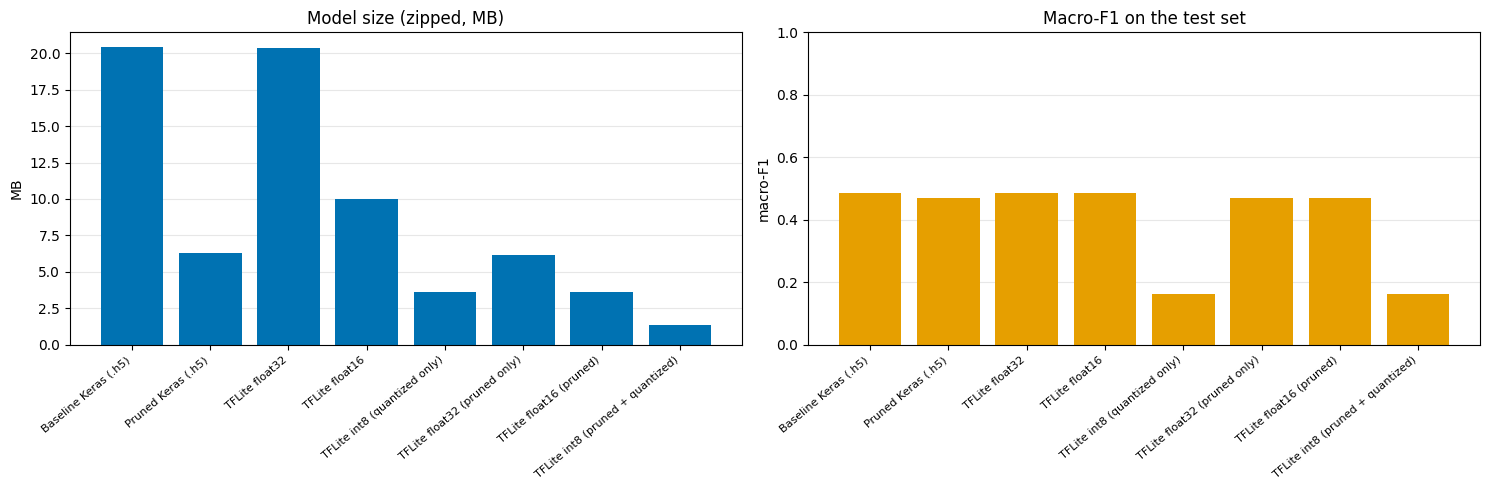

In [47]:
# size and macro-F1 side by side

labels = [r['model'] for r in results]
x = np.arange(len(labels))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].bar(x, [r['zip_mb'] for r in results], color='#0072B2')
ax[0].set_title('Model size (zipped, MB)')
ax[0].set_ylabel('MB')

ax[1].bar(x, [r['macro_f1'] for r in results], color='#E69F00')
ax[1].set_title('Macro-F1 on the test set')
ax[1].set_ylabel('macro-F1')
ax[1].set_ylim(0, 1.0)

for a in ax:
    a.set_xticks(x)
    a.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    a.grid(axis='y', alpha=0.3)
    a.set_axisbelow(True)

plt.tight_layout()
plt.show()


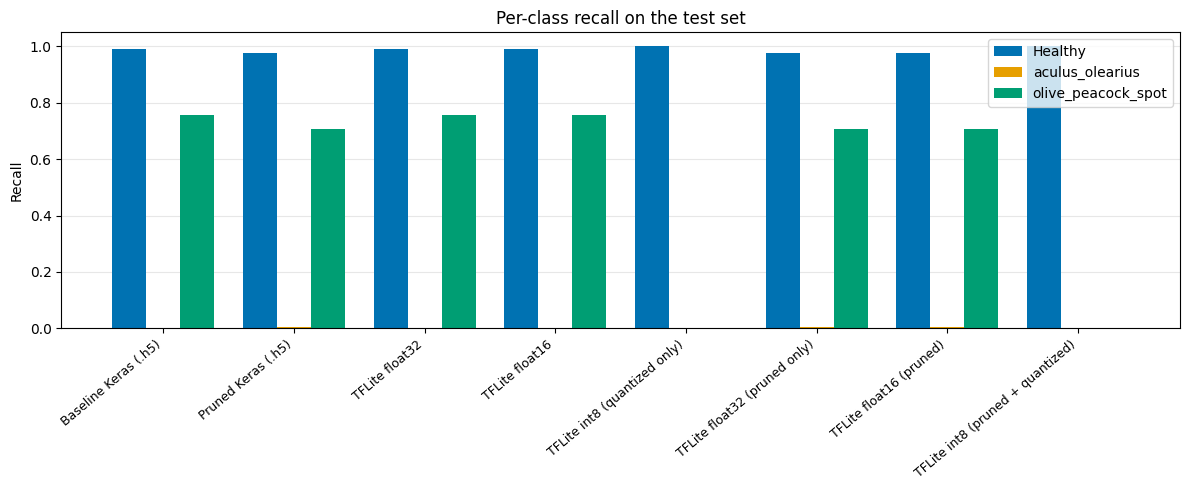

In [48]:
# per-class recall - the chart that shows whether one class took the damage

width = 0.26
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width, [r['rec_healthy'] for r in results], width, label='Healthy', color='#0072B2')
ax.bar(x,         [r['rec_aculus']  for r in results], width, label='aculus_olearius', color='#E69F00')
ax.bar(x + width, [r['rec_peacock'] for r in results], width, label='olive_peacock_spot', color='#009E73')

ax.set_ylabel('Recall')
ax.set_title('Per-class recall on the test set')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [49]:
# full per-class report for the three models that matter most

for name in ['Baseline Keras (.h5)',
             'TFLite int8 (quantized only)',
             'TFLite float32 (pruned only)',
             'TFLite int8 (pruned + quantized)']:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_true, predictions[name],
                                target_names=CLASSES, digits=3, zero_division=0))


Baseline Keras (.h5)
                    precision    recall  f1-score   support

           Healthy      0.486     0.991     0.652       220
   aculus_olearius      0.000     0.000     0.000       200
olive_peacock_spot      0.857     0.758     0.804       260

          accuracy                          0.610       680
         macro avg      0.447     0.583     0.485       680
      weighted avg      0.485     0.610     0.518       680

TFLite int8 (quantized only)
                    precision    recall  f1-score   support

           Healthy      0.324     1.000     0.489       220
   aculus_olearius      0.000     0.000     0.000       200
olive_peacock_spot      0.000     0.000     0.000       260

          accuracy                          0.324       680
         macro avg      0.108     0.333     0.163       680
      weighted avg      0.105     0.324     0.158       680

TFLite float32 (pruned only)
                    precision    recall  f1-score   support

           Hea

### Why a quantized model can collapse - the diagnostic

If the int8 rows lost accuracy, this cell shows the mechanism rather than just the symptom.

Quantization does not round each weight independently. It picks **256 evenly spaced values** covering
the full range of a weight tensor, from its most negative weight to its most positive one, and stores
each weight as an index into that list plus one shared scale factor. So the spacing between
neighbouring representable values - the *step size* - is set by the **widest** weight in the tensor.

That has a consequence worth stating in the report: **a single outlier weight makes every other
weight in that layer coarser.** If a layer's weights are mostly small but one is very large, the
useful weights end up crowded into a handful of the 256 available slots.

The cell prints, for each layer, the ratio of the largest weight to the typical one. A high ratio
means the layer is a bad candidate for per-tensor quantization.


In [50]:
print(f"{'layer':<22}{'max |w|':>12}{'median |w|':>14}{'ratio':>10}{'step size':>13}")
print("-" * 71)

for layer in model_for_pruning.layers:
    if isinstance(layer, (Conv2D, Dense)):
        kernel = layer.get_weights()[0]
        nonzero = np.abs(kernel[kernel != 0])       # ignore the pruned weights
        mx = nonzero.max()
        med = np.median(nonzero)
        step = 2 * mx / 255.0                       # 256 levels across [-max, +max]
        print(f"{layer.name:<22}{mx:>12.4f}{med:>14.4f}{mx / med:>10.1f}{step:>13.5f}")

print()
print("A weight smaller than half the step size quantizes to exactly zero.")


layer                      max |w|    median |w|     ratio    step size
-----------------------------------------------------------------------
conv2d_2                    0.1326        0.1030       1.3      0.00104
conv2d_3                    0.1214        0.0653       1.9      0.00095
dense_2                     0.1210        0.0127       9.5      0.00095
dense_3                     0.3968        0.1529       2.6      0.00311

A weight smaller than half the step size quantizes to exactly zero.


## Compression and the saliency maps

One consequence is easy to miss and it connects straight back to the Grad-CAM++ section of the main
notebook.

Grad-CAM++ works by differentiating a class score with respect to a convolutional feature map, so it
needs a **differentiable** model. A Keras model is, including a pruned one - pruning only sets
weights to zero and leaves the graph intact. A quantized TFLite model is not: it is a frozen graph of
fixed operations with no trainable variables and nothing to take a gradient of.

The model we would actually deploy to a phone is the quantized one, and it is precisely the model
Grad-CAM++ cannot explain. Either ship the pruned Keras model and accept the larger file, or use a
perturbation-based method such as LIME or SHAP, which needs only forward passes and therefore works
on anything.


In [51]:
# Keras models carry trainable variables, so Grad-CAM++ can differentiate them

print("Baseline Keras - trainable tensors :", len(model.trainable_variables))
print("Pruned   Keras - trainable tensors :", len(model_for_pruning.trainable_variables))

interpreter = tf.lite.Interpreter(model_path=tflite_files['pruned_int8'])
interpreter.allocate_tensors()

print("TFLite interpreter - has trainable_variables:", hasattr(interpreter, 'trainable_variables'))
print("TFLite interpreter - what it exposes instead:",
      [d['name'] for d in interpreter.get_input_details()],
      "->",
      [d['name'] for d in interpreter.get_output_details()])


Baseline Keras - trainable tensors : 8
Pruned   Keras - trainable tensors : 8
TFLite interpreter - has trainable_variables: False
TFLite interpreter - what it exposes instead: ['serving_default_conv2d_2_input:0'] -> ['StatefulPartitionedCall:0']


---
# Explaining pruning and quantization

Written to be read by someone who is not a machine learning specialist, but without giving them a
picture that falls apart under a follow-up question.

## The one-line version

> **Pruning changes how many numbers the model keeps. Quantization changes how precisely each
> surviving number is written down.**

Those are two independent axes, which is exactly why the two techniques stack: one reduces the
*count*, the other reduces the *cost per item*. Everything below expands on that sentence.

## Why there is anything to remove in the first place

The usual explanation is that a trained network contains "dead branches" that were never useful.
That is not quite right, and the difference matters.

A network is deliberately built **larger than the job needs**, because a big network is far easier to
*train* than a small one. The spare capacity gives gradient descent room to manoeuvre - more paths
downhill, fewer places to get stuck. It is scaffolding for the construction process.

Once training finishes, the scaffolding is still bolted to the building. Pruning and quantization are
two ways of asking the same question: *now that the model has learned the job, what does it actually
take to do the job?*

This is why compression works so well and so reliably. We are not finding mistakes. We are removing
something that was doing a real job during training and has no job left.

## Pruning - keeping fewer numbers

A neural network layer computes a weighted sum: every input is multiplied by a weight and the results
are added up. A weight is simply *how much attention this layer pays to that input*.

After training, the weights are not spread evenly. Most sit very close to zero, and a small minority
carry most of the signal. A weight of 0.0001 multiplies its input down to nothing - it is a vote of
almost no confidence. Setting it to exactly zero changes the output by almost nothing.

**Analogy.** A large orchestra where most players are holding their instruments but barely playing.
Send them home and the piece still sounds the same. Pruning identifies who is actually playing by
looking at how loudly - which is exactly what "magnitude pruning" means.

**Where the analogy needs care.** Sending home a hundred musicians who were each playing very quietly
does change the sound a little, and those small changes add up over five million weights. That is why
the recipe is *train, prune, **retrain*** rather than just *train, prune*. The retraining step lets
the remaining players adjust their volume to cover what was lost. Skipping it is the single most
common reason pruning appears not to work.

## Quantization - writing each number less precisely

The usual explanation is rounding: 175.4832 cm becomes 175 cm, close enough. True, but it hides the
part that actually determines whether quantization succeeds or fails.

Quantization does not round each number on its own. For a whole layer at once, it chooses **256
evenly spaced values** - that is all 8 bits can address - stretching from the most negative weight in
that layer to the most positive one. Every weight is then stored as a one-byte index into that list,
plus a single shared scale factor for the layer.

**Analogy.** You are given a ruler with exactly 256 marks on it and told to measure everything in the
room with it. If the room contains objects from 1 cm to 100 cm, the marks land about every 0.4 cm and
everything is measured well. But if one object is 10 metres long, the ruler has to stretch to cover
it, the marks now land every 4 cm, and **every small object is measured badly** - because of one
large object that had nothing to do with them.

That is the real risk in quantization, and it is not obvious from the rounding story: **one outlier
weight degrades the precision of every other weight in its layer.** The diagnostic cell above prints
exactly this ratio for each of our layers.

There is a second effect that compounds it. Each layer's small rounding errors become the *input* to
the next layer, which multiplies them by its own weights before adding its own errors. Errors do not
just accumulate, they get amplified on the way through. A model that finishes with a wide margin
between its class scores absorbs this easily. A model whose top two classes are nearly tied does not
- the accumulated noise is enough to flip the answer.

**This is the honest reason a weak model is fragile under quantization.** It is not that quantization
is unpredictable. It is that quantization eats decision margin, and a model that never had much
margin has nothing to give.

## Why the file does not shrink when you prune

This is the part almost every explanation gets wrong, and our own results demonstrate it directly.

Pruning replaces small weights with zeros. It does **not** delete them - the model has exactly the
same shape, the same layers and the same number of parameters, and each of those parameters is still
stored as a 32-bit float. A zero stored as a 32-bit float takes 32 bits, precisely as much room as
any other number.

So the pruned `.h5` file is **byte for byte the same size** as the original. Compare those two rows
in the size table above.

The saving is real, it is just latent. Zeros compress extremely well, because a compressor can record
"four thousand zeros" in a few bytes instead of writing out four thousand numbers. So the pruned file
shrinks dramatically the moment it is zipped - and that is a fair thing to report, because a model
downloaded to a phone is downloaded compressed.

**The two techniques attack the file in genuinely different ways:**

- **Quantization** shrinks the file *immediately*, because every number is physically smaller: one
  byte instead of four.
- **Pruning** shrinks the file *only once it is compressed*, because it does not make numbers
  smaller, it makes them repetitive.

Which is another way of saying they are not competing - they are complementary, and that is why
Han et al.'s *Deep Compression* applies both.

## Packing for a trip - the analogy, corrected

The familiar version says pruning is leaving clothes behind and quantization is decanting liquids
into lighter bottles. The second half is right. The first half is misleading, because pruning does
not remove anything from the suitcase.

A closer version:

- **Pruning** is folding the clothes you do not need flat and stacking them identically, so the
  suitcase can be **vacuum-packed** down to a fraction of its size. Take the vacuum off and it
  springs back to full volume - which is what "the `.h5` file is the same size" means.
- **Quantization** is decanting from glass into plastic. Permanently lighter, whatever you do next.
- Together: **vacuum-pack the clothes and swap the bottles.** Our own run went from about 20 MB to
  about 1.4 MB, which is roughly fourteen times smaller.

## What compression costs, and why accuracy hides it

The last piece is what you give up, and here the standard summary - "accuracy drops a little, often
barely noticeable" - is true on average and misleading in exactly the cases that matter.

Hooker et al. (2019) asked what compressed models actually *forget*. Top-line accuracy barely moved,
but the damage was not spread evenly across the data. It concentrated in a small set of examples they
called *compression-identified exemplars* - and those turned out to be disproportionately the
**atypical and underrepresented** ones. A follow-up study found the same effect showing up as
amplified bias against underrepresented groups.

The reason is worth understanding, because it follows from everything above. Compression eats
decision margin. Common, prototypical examples are classified with a large margin and survive.
Borderline examples from small classes were already close to the decision boundary, so they are the
first to cross it. Averaging over the whole test set makes this invisible.

For our dataset that is a specific, testable prediction: if compression hurts, it will hurt
`aculus_olearius` - the smallest class - first and hardest, and **overall accuracy will not show it.**
That is why every table in this notebook reports macro-F1 and per-class recall alongside accuracy,
and why the per-class recall chart is the one to put in the report.

## Summary

| | Pruning | Quantization |
|---|---|---|
| **Question it asks** | Which numbers can we drop? | How cheaply can we store each one? |
| **What it changes** | how many weights are non-zero | how many bits per weight |
| **Model shape** | unchanged - the zeros stay in place | unchanged |
| **File size on disk** | **no change** until compressed | ~4x smaller immediately (32-bit to 8-bit) |
| **Needs retraining?** | yes, to recover accuracy | no - applied after training |
| **Main risk** | pruning small layers that cannot spare weights | one outlier weight coarsening a whole layer |
| **Speed** | only with hardware that skips zeros | yes - integer arithmetic is faster |
| **Still explainable?** | yes - stays differentiable, Grad-CAM++ works | no - frozen graph, needs LIME/SHAP |

**In one sentence each:**

- **Pruning asks:** *which parts can we remove, and can the rest cover for them?*
- **Quantization asks:** *how roughly can we write down what is left before the answers start
  changing?*


---
# Notes for the write-up - defending each deviation

Five places where this notebook differs from the class exercise, and the one-line answer for each.

**1. Why not use `tensorflow-model-optimization`?**
Magnitude pruning is Han et al.'s method and it is a percentile and a mask. Writing it out removes a
dependency that is awkward to install against our TensorFlow version, and it means every line here
can be accounted for.

**2. Why does the pruned model summary not double in size like the exercise's did?**
The toolkit wraps every layer and stores a mask and a threshold variable next to each kernel, which
is what doubles the count. Ours keeps the mask in a Python dictionary outside the model, so the
parameter count is unchanged - and there is nothing to strip off afterwards.

**3. Why is a callback needed at all?**
Gradient descent does not know those weights are meant to be zero. Without re-applying the mask
after each batch the optimizer moves them straight off zero and the pruning is undone by the end of
the first epoch. This is what the toolkit's `UpdatePruningStep` does too.

**4. Why threshold per layer instead of globally?**
Nearly all the weights sit in the one Dense layer after `Flatten`, and it operates on a different
scale to the two convolutional layers. A single global threshold would zero the conv layers
completely and leave the dense layer barely touched.

**5. Why is the output layer excluded from pruning?**
It holds 192 of 5.77 million weights, so pruning it saves nothing measurable, but at 80% sparsity it
leaves about thirteen weights per class to decide the whole output. `tfmot`'s own guide recommends
excluding the final classification layer for this reason. Set `PRUNE_OUTPUT_LAYER = True` to
reproduce the first run, where it was pruned to 79.7% and the quantized model collapsed to a single
class.

## One honest caveat about this baseline

`modelBest` scores 61.03% on the test set with recall on `aculus_olearius` of **0.000** - that class
was never learned. This limits what the study can show: **you cannot measure compression damaging a
class the model never learned in the first place.** `rec_aculus` reads 0.00 in the baseline row, so
Hooker et al.'s minority-class effect cannot be tested on this model.

The size results are valid regardless, and "the minority-class effect could not be tested because the
baseline had already collapsed on that class" is an honest finding worth stating. If there is time
for a second run, point `MODEL_DIR` at the saved DenseNet121 model (around 94.7% on test with
balanced per-class recall) and change the three generators from `rescale=1./255` to
`preprocessing_function=preprocess_input`. That model has something to lose, so the compression study
can actually measure a loss. The rebuild cell is the only other thing that needs changing - for the
DenseNet you can prune the loaded model directly, since `prune_low_magnitude` only looks for `Conv2D`
and `Dense` layers and does not care how the model was built.

## References

Han, S., Pool, J., Tran, J. and Dally, W. J. 2015. Learning both weights and connections for
efficient neural networks. *NeurIPS* 28, 1135-1143.

Han, S., Mao, H. and Dally, W. J. 2016. Deep compression: compressing deep neural networks with
pruning, trained quantization and Huffman coding. *ICLR*.

Zhu, M. and Gupta, S. 2017. To prune, or not to prune: exploring the efficacy of pruning for model
compression. *arXiv:1710.01878*.

Jacob, B. et al. 2018. Quantization and training of neural networks for efficient
integer-arithmetic-only inference. *CVPR*, 2704-2713.

Krishnamoorthi, R. 2018. Quantizing deep convolutional networks for efficient inference: a
whitepaper. *arXiv:1806.08342*.

Hooker, S., Courville, A., Clark, G., Dauphin, Y. and Frome, A. 2019. What do compressed deep neural
networks forget? *arXiv:1911.05248*.

Hooker, S., Moorosi, N., Clark, G., Bengio, S. and Denton, E. 2020. Characterising bias in compressed
models. *arXiv:2010.03058*.
